In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,roc_curve,classification_report
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


In [61]:
df = pd.read_csv("agriculture_dataset.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


First 5 rows:
   rainfall  temperature  soil_moisture  soil_pH  nitrogen  phosphorus  \
0    878.92        15.72          68.08     4.73    145.19       45.98   
1    943.87        25.53          57.78     7.26    127.16      128.22   
2   1894.62        12.48          62.58     7.33     55.40       43.43   
3    275.11        13.18          40.85     7.80    132.63      134.42   
4    552.45        17.86          43.33     5.41     96.79       36.39   

   potassium  irrigation  crop_area  fertilizer  pesticide  sunlight  \
0      17.52       50.18     339.43      205.99      48.33      6.48   
1      91.25       80.02     126.62      183.27      16.69      5.66   
2     133.92       76.97      63.67      143.93      21.41     10.31   
3      39.60       13.25     377.55      251.53      17.38      7.84   
4      39.67       83.85     153.58      258.12      17.99      5.36   

   humidity  altitude  wind_speed  groundwater  crop_diversity  mechanization  \
0     71.45    986.99      

In [62]:
# ================= EDA =================
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
rainfall          0
temperature       0
soil_moisture     0
soil_pH           0
nitrogen          0
phosphorus        0
potassium         0
irrigation        0
crop_area         0
fertilizer        0
pesticide         0
sunlight          0
humidity          0
altitude          0
wind_speed        0
groundwater       0
crop_diversity    0
mechanization     0
yield_variance    0
avg_yield         0
dtype: int64


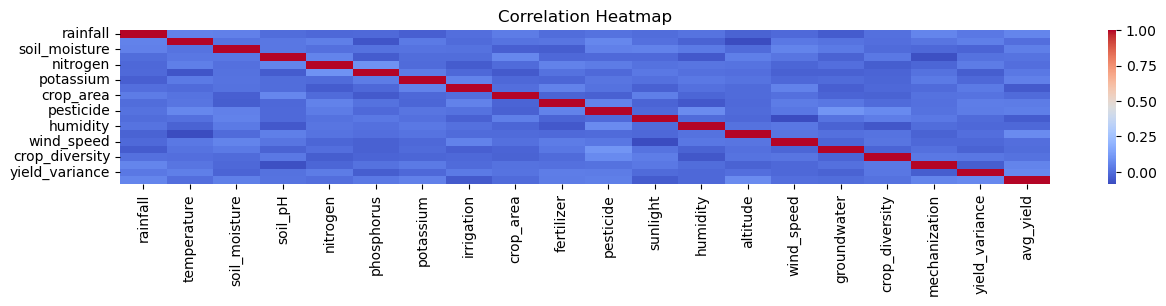

In [63]:
# Correlation Heatmap
plt.figure(figsize=(15,2))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

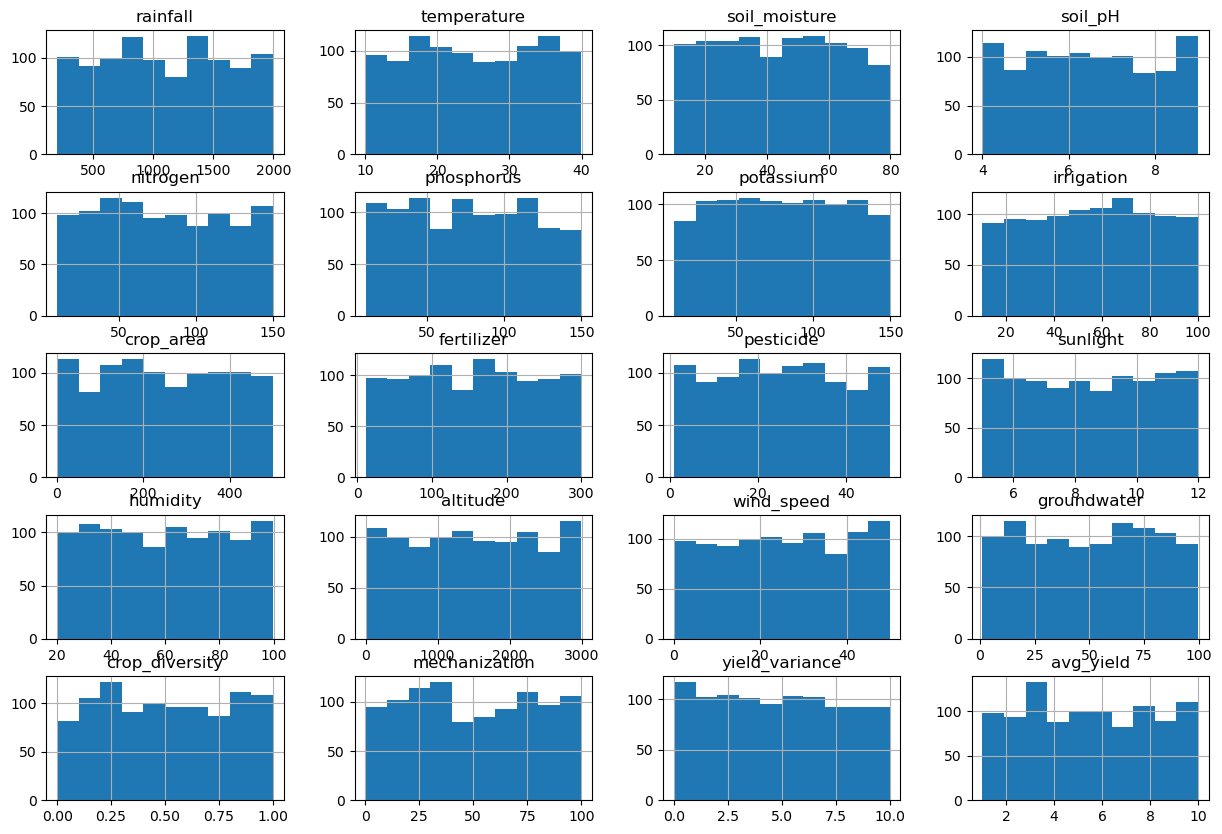

In [64]:
# Histogram
df.hist(figsize=(15,10))
plt.show()


In [65]:
# ================= DATA PREPROCESSING =================
# Fill missing values
df.fillna(df.mean(), inplace=True)

# Outlier Removal (IQR Method)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df < (Q1 - 1.5*IQR)) | (df > (Q3 + 1.5*IQR))).any(axis=1)]

print("\nShape after removing outliers:", df_clean.shape)


Shape after removing outliers: (1000, 20)


In [66]:
# ================= FEATURE SCALING =================
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

In [67]:
# ================= PCA (FOR VISUALIZATION) =================
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(df_scaled)

C:\Users\Aman Rana\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Aman Rana\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Aman Rana\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Aman Rana\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memor

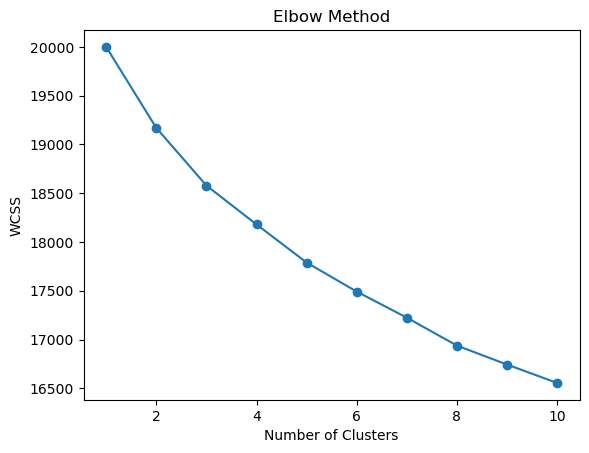

In [68]:
# ================= ELBOW METHOD =================
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


In [69]:
# ================= APPLY K-MEANS =================
k = 3   # choose based on elbow graph
kmeans = KMeans(n_clusters=k, random_state=42)

clusters = kmeans.fit_predict(df_scaled)

# Add cluster column
df_clean['Cluster'] = clusters


C:\Users\Aman Rana\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


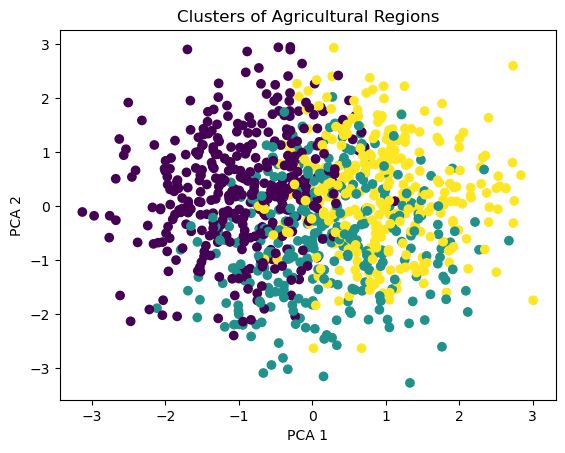

In [70]:
# ================= VISUALIZATION =================
plt.scatter(reduced_data[:,0], reduced_data[:,1], c=clusters)
plt.title("Clusters of Agricultural Regions")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [71]:
# ================= EVALUATION =================
score = silhouette_score(df_scaled, clusters)
print("\nSilhouette Score:", score)


Silhouette Score: 0.03701922129381847


In [72]:
# ================= PREDICTION FOR NEW DATA =================
# Example new region data (20 features)
new_data = [[
    800, 25, 40, 6.5, 80, 60, 70, 50, 200, 150,
    20, 8, 60, 500, 10, 30, 0.5, 60, 3, 5
]]


In [73]:
# Scale new data
new_scaled = scaler.transform(new_data)

C:\Users\Aman Rana\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [74]:
# Predict cluster
predicted_cluster = kmeans.predict(new_scaled)

print("\nPredicted Cluster for New Data:", predicted_cluster)


Predicted Cluster for New Data: [0]


In [75]:
# clusters becomes target variable
y = clusters

# Use PCA reduced data as X
X = reduced_data

# ================= TRAIN TEST SPLIT =================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================= CLASSIFIER =================
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# ================= REPORT =================
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.69      0.69        75
           1       0.43      0.51      0.47        51
           2       0.68      0.59      0.63        74

    accuracy                           0.61       200
   macro avg       0.60      0.60      0.60       200
weighted avg       0.62      0.61      0.61       200

Confusion Matrix:

[[52 14  9]
 [13 26 12]
 [10 20 44]]


Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.69      0.69        75
           1       0.43      0.51      0.47        51
           2       0.68      0.59      0.63        74

    accuracy                           0.61       200
   macro avg       0.60      0.60      0.60       200
weighted avg       0.62      0.61      0.61       200



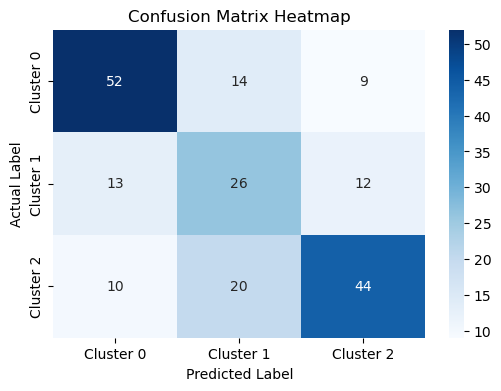

In [80]:
# ================= REPORT =================
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# ================= CONFUSION MATRIX PLOT =================
cm = confusion_matrix(y_test, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cluster 0','Cluster 1','Cluster 2'],
            yticklabels=['Cluster 0','Cluster 1','Cluster 2'])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()